# Project Check-In: Initial Machine Learning and Bivariate Data Visualizations
Cassady Jackson and Baylie Schnieder

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, r2_score, f1_score
from scipy import stats

In [11]:
state_data = pd.read_csv('State_Unique_Data.csv')

In [12]:
state_data

,YearStart,YearEnd,LocationAbbr,State,DataSource,Topic,Question,DataValueUnit,DataValueType,DataValue,...,TopicID,QuestionID,DataValueTypeID,StratificationCategoryID1,StratificationID1,Overall Public School Rank 2024,K-12 Performance 2024,School Funding and Resources 2024,Higher Ed Quality 2024,School Safety Rank 2024
0,2019,2019,AR,Arkansas,BRFSS,Diabetes,Diabetes among adults,%,Crude Prevalence,13.6,...,DIA,DIA01,CRDPREV,SEX,SEXM,45,42,35,30,43
1,2019,2019,ID,Idaho,BRFSS,Diabetes,Diabetes among adults,%,Crude Prevalence,10.6,...,DIA,DIA01,CRDPREV,SEX,SEXM,47,21,48,39,3
2,2019,2019,IA,Iowa,BRFSS,Asthma,Current asthma among adults,%,Crude Prevalence,10.3,...,AST,AST02,CRDPREV,AGE,AGE1844,22,12,36,26,42
3,2019,2019,IA,Iowa,BRFSS,Health Status,Recent activity limitation among adults,Number,Crude Mean,2.3,...,HEA,HEA04,CRDMEAN,SEX,SEXF,22,12,36,26,42
4,2019,2019,IA,Iowa,BRFSS,Mental Health,Depression among adults,%,Crude Prevalence,31.0,...,MEN,MEN02,CRDPREV,RACE,MRC,22,12,36,26,42
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
179610,2022,2022,WV,West Virginia,BRFSS,Mental Health,Frequent mental distress among adults,%,Age-adjusted Prevalence,26.0,...,MEN,MEN05,AGEADJPREV,SEX,SEXF,46,50,34,31,41
179611,2022,2022,VT,Vermont,BRFSS,Sleep,Short sleep duration among adults,%,Crude Prevalence,26.5,...,SLEP,SLP03,CRDPREV,RACE,ASN,6,5,6,50,26
179612,2022,2022,WV,West Virginia,BRFSS,Chronic Obstructive Pulmonary Disease,Chronic obstructive pulmonary disease among ad...,%,Crude Prevalence,14.0,...,COPD,COPD01,CRDPREV,OVERALL,OVR,46,50,34,31,41
179613,2022,2022,WI,Wisconsin,BRFSS,Immunization,Pneumococcal vaccination among adults aged 65 ...,%,Crude Prevalence,64.2,...,IMM,IMM04,CRDPREV,RACE,BLK,10,10,25,19,20


In [13]:
dummies2 = pd.get_dummies(state_data['Topic'])

states_data = pd.concat([state_data, dummies2], axis=1)
states_data.drop(['StratificationID1','StratificationCategoryID1','DataValueTypeID','QuestionID', 'TopicID', 'StratificationCategory1', 'DataValueType', 'DataValueUnit', 'Question','DataSource', 'LocationID', 'Stratification1', 'LocationAbbr', 'State', 'Topic', 'YearStart', 'YearEnd', 'K-12 Performance 2024','School Funding and Resources 2024', 'Higher Ed Quality 2024', 'School Safety Rank 2024', 'DataValue', 'DataValueAlt', 'LowConfidenceLimit', 'HighConfidenceLimit' ], axis=1, inplace=True)
display(states_data)

,Overall Public School Rank 2024,Alcohol,Arthritis,Asthma,Cancer,Cardiovascular Disease,Chronic Obstructive Pulmonary Disease,Cognitive Health and Caregiving,Diabetes,Disability,Health Status,Immunization,Maternal Health,Mental Health,"Nutrition, Physical Activity, and Weight Status",Oral Health,Sleep,Social Determinants of Health,Tobacco
0,45,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
1,47,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
2,22,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,22,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
4,22,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
179610,46,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False
179611,6,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
179612,46,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
179613,10,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False


### Linear Regression:

In [15]:
states_data.head()
X = states_data.drop('Overall Public School Rank 2024', axis=1)
y = states_data['Overall Public School Rank 2024'].values
X_train, X_test, y_train, y_test = train_test_split(X ,y, test_size = 0.2, random_state = 42)
Lin_Regression = LinearRegression().fit(X_train, y_train)
y_pre = Lin_Regression.predict(X_test)
Lin_Regression.score(X_test, y_test)

-7.056215401313182e-05

break it up into the best 10 and lowest 10 and use the other features to predict whether it is a high state or low state - use classification to see if it is a better machine learning outcome. 

think about adjusting for population, per capita so it is more accurate

include a timeseries at the end with all of the years that we have data for

final report is 6-8 pages and is an expansion of the analysis we did there. 

do some groupings to be able to better understand

In [16]:
import matplotlib.pyplot as plt 

In [17]:
low_df = state_data[(state_data['Overall Public School Rank 2024'] <= 25)]
display(low_df)

,YearStart,YearEnd,LocationAbbr,State,DataSource,Topic,Question,DataValueUnit,DataValueType,DataValue,...,TopicID,QuestionID,DataValueTypeID,StratificationCategoryID1,StratificationID1,Overall Public School Rank 2024,K-12 Performance 2024,School Funding and Resources 2024,Higher Ed Quality 2024,School Safety Rank 2024
2,2019,2019,IA,Iowa,BRFSS,Asthma,Current asthma among adults,%,Crude Prevalence,10.3,...,AST,AST02,CRDPREV,AGE,AGE1844,22,12,36,26,42
3,2019,2019,IA,Iowa,BRFSS,Health Status,Recent activity limitation among adults,Number,Crude Mean,2.3,...,HEA,HEA04,CRDMEAN,SEX,SEXF,22,12,36,26,42
4,2019,2019,IA,Iowa,BRFSS,Mental Health,Depression among adults,%,Crude Prevalence,31.0,...,MEN,MEN02,CRDPREV,RACE,MRC,22,12,36,26,42
6,2019,2019,MD,Maryland,YRBSS,Alcohol,Alcohol use among high school students,%,Crude Prevalence,21.0,...,ALC,ALC01,CRDPREV,SEX,SEXM,12,28,10,18,27
7,2019,2019,MD,Maryland,BRFSS,Mental Health,Depression among adults,%,Crude Prevalence,19.2,...,MEN,MEN02,CRDPREV,SEX,SEXF,12,28,10,18,27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
179607,2022,2022,VA,Virginia,BRFSS,Health Status,Frequent physical distress among adults,%,Age-adjusted Prevalence,12.2,...,HEA,HEA03,AGEADJPREV,RACE,WHT,9,19,21,11,17
179609,2022,2022,VA,Virginia,BRFSS,Tobacco,Current cigarette smoking among adults,%,Age-adjusted Prevalence,12.3,...,TOB,TOB04,AGEADJPREV,OVERALL,OVR,9,19,21,11,17
179611,2022,2022,VT,Vermont,BRFSS,Sleep,Short sleep duration among adults,%,Crude Prevalence,26.5,...,SLEP,SLP03,CRDPREV,RACE,ASN,6,5,6,50,26
179613,2022,2022,WI,Wisconsin,BRFSS,Immunization,Pneumococcal vaccination among adults aged 65 ...,%,Crude Prevalence,64.2,...,IMM,IMM04,CRDPREV,RACE,BLK,10,10,25,19,20


In [18]:
high_df = state_data[(state_data['Overall Public School Rank 2024'] > 25)]
display(high_df)

,YearStart,YearEnd,LocationAbbr,State,DataSource,Topic,Question,DataValueUnit,DataValueType,DataValue,...,TopicID,QuestionID,DataValueTypeID,StratificationCategoryID1,StratificationID1,Overall Public School Rank 2024,K-12 Performance 2024,School Funding and Resources 2024,Higher Ed Quality 2024,School Safety Rank 2024
0,2019,2019,AR,Arkansas,BRFSS,Diabetes,Diabetes among adults,%,Crude Prevalence,13.6,...,DIA,DIA01,CRDPREV,SEX,SEXM,45,42,35,30,43
1,2019,2019,ID,Idaho,BRFSS,Diabetes,Diabetes among adults,%,Crude Prevalence,10.6,...,DIA,DIA01,CRDPREV,SEX,SEXM,47,21,48,39,3
5,2019,2019,LA,Louisiana,BRFSS,Mental Health,Depression among adults,%,Crude Prevalence,29.3,...,MEN,MEN02,CRDPREV,RACE,HIS,42,45,46,22,23
9,2019,2019,MS,Mississippi,BRFSS,Arthritis,Severe joint pain among adults with arthritis,%,Crude Prevalence,37.6,...,ART,ART03,CRDPREV,SEX,SEXM,39,46,38,32,16
12,2019,2019,NV,Nevada,YRBSS,Alcohol,Alcohol use among high school students,%,Crude Prevalence,29.0,...,ALC,ALC01,CRDPREV,GRADE,GRD11,44,44,45,16,46
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
179597,2022,2022,WV,West Virginia,BRFSS,Disability,Adults with any disability,%,Crude Prevalence,29.2,...,DIS,DIS01,CRDPREV,RACE,BLK,46,50,34,31,41
179602,2022,2022,UT,Utah,BRFSS,Tobacco,Current cigarette smoking among adults,%,Crude Prevalence,7.1,...,TOB,TOB04,CRDPREV,RACE,HIS,37,4,51,40,35
179608,2022,2022,UT,Utah,BRFSS,Social Determinants of Health,"Unable to pay mortgage, rent, or utility bills...",%,Age-adjusted Prevalence,7.4,...,SDOH,SDH05,AGEADJPREV,RACE,WHT,37,4,51,40,35
179610,2022,2022,WV,West Virginia,BRFSS,Mental Health,Frequent mental distress among adults,%,Age-adjusted Prevalence,26.0,...,MEN,MEN05,AGEADJPREV,SEX,SEXF,46,50,34,31,41


## Scatterplot for States with Highest Ranking vs Rate of Chronic Illness

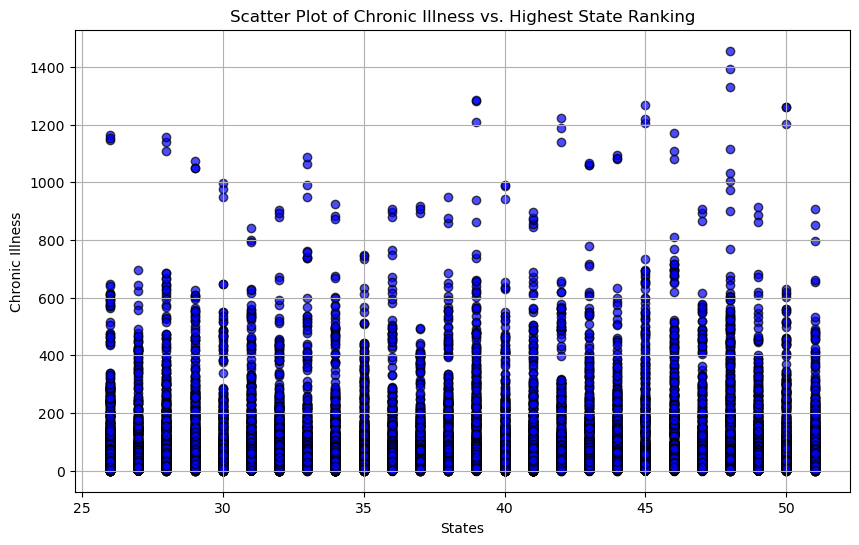

In [20]:
plt.figure(figsize=(10, 6)) # size of the plot in inches (width, height)
plt.scatter(high_df['Overall Public School Rank 2024'], high_df['DataValue'], c='blue', edgecolors='black', alpha=0.7)
plt.title('Scatter Plot of Chronic Illness vs. Highest State Ranking')
plt.xlabel('States')
plt.ylabel('Chronic Illness')
plt.grid(True)
plt.show()

### Scatterplot for States with Lowest Ranking vs Chronic Illness

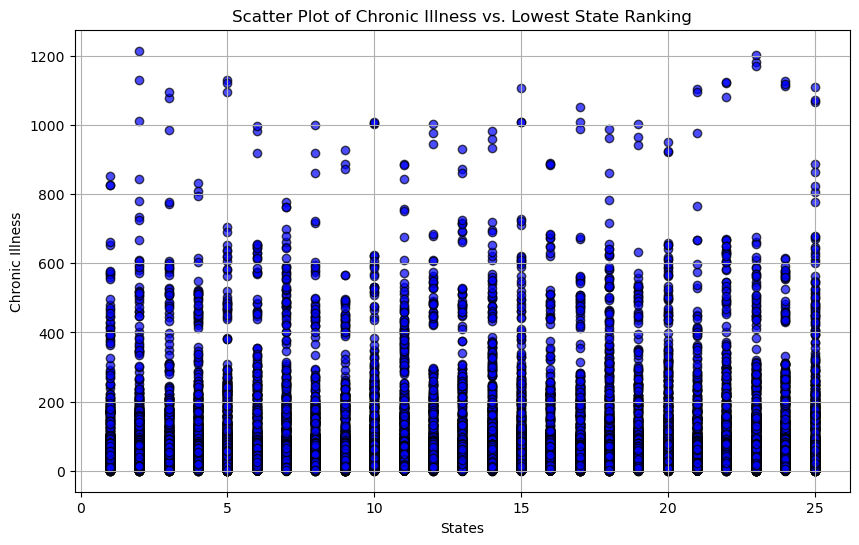

In [22]:
plt.figure(figsize=(10, 6)) # size of the plot in inches (width, height)
plt.scatter(low_df['Overall Public School Rank 2024'], low_df['DataValue'], c='blue', edgecolors='black', alpha=0.7)
plt.title('Scatter Plot of Chronic Illness vs. Lowest State Ranking')
plt.xlabel('States')
plt.ylabel('Chronic Illness')
plt.grid(True)
plt.show()